# Risk-Based Mainenance Decision Support

Raw Machine Data > Machine Learning Models > Failure Probability > Risk Assessment > Maintenance Prioritization > Business Impact > Recommendation

## 1. Introduction

Manufacturing plants lose money through unexpected equipment failures. This project investigates whether machine learning can identify high-risk operating conditions and support maintenance planning in industrial settings.

This project explores two main questions:

* **What patterns exist in the data that we don't already know about?** *(Unsupervised Learning)*
* **Can we predict whether a machine will fail?** *(Supervised Learning)*

The resulting predictions are then combined with business logic to support maintenance decision-making, including determining which machines should be repaired first and estimating the potential operational impact of equipment failures.

## 2. Dataset

The **AI4I 2020 Predictive Maintenance Dataset** was selected because it closely matches the industrial manufacturing context of this project while supporting all of the required machine learning techniques. The dataset is well suited for data preprocessing, exploratory data analysis, unsupervised learning (K-Means clustering), dimensionality reduction (PCA and UMAP), supervised learning (e.g., Logistic Regression, Random Forest, and XGBoost), and deep learning using neural networks.

Additionally, the dataset frames the problem as a binary classification task, allowing machine learning models to predict the probability of equipment failure under different operating conditions.

**Dataset Source**

* AI4I 2020 Predictive Maintenance Dataset: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

### Features

The dataset contains **10,000 observations** and **14 variables**, including both categorical and numerical features describing industrial equipment and its operating conditions.

The primary input features used in this project are:

* Machine Type
* Air Temperature
* Process Temperature
* Rotational Speed
* Torque
* Tool Wear

Additional variables include a unique identifier (**UDI**), **Product ID**, and five binary indicators representing specific failure types (**TWF**, **HDF**, **PWF**, **OSF**, and **RNF**). These variables will be evaluated during data preprocessing to determine whether they should be included in the predictive models.

### Target Variable

The target variable for this project is **Machine failure**, a binary variable where:

* **0** = No machine failure
* **1** = Machine failure

The dataset is imbalanced, with machine failures representing approximately **3.39%** of all observations. This reflects real industrial operating conditions where equipment failures are relatively uncommon and highlights the importance of using evaluation metrics beyond overall accuracy.

## 3. Imports

In [6]:
# Standard imports
import os

#os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # keep as fallback, but shouldn't be needed now
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Model Persistence
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

# TensorFlow
import tensorflow as tf
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping

# XGBoost
from xgboost import XGBClassifier

# UMAP
import umap

## 4. Data Loading and Initial Overview

### 4.1 Load the Dataset

In [7]:
from pathlib import Path

print(Path.cwd())

/Users/victoria/dev/aikurs/industrial-maintenance-project/notebooks


In [8]:
df = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"
)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 4.2 Dataset Dimensions

In [9]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 10000
Columns: 14


### 4.3 Summary Statistics

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


### 4.4 Missing Values

In [12]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### 4.5 Duplicate Rows

In [13]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


### 4.6 Initial Overview

The AI4I 2020 Predictive Maintenance dataset contains 10,000 observations and 14 variables. The dataset includes a combination of numerical and categorical features describing machine operating conditions, along with a binary target variable indicating whether a machine failure occurred.

Initial inspection shows that:

- The dataset contains 10,000 rows and 14 columns.
- There are no missing values or duplicate records.
- Numerical features include temperatures, rotational speed, torque, and tool wear.
- Categorical features include Product ID and Machine Type.
- The target variable, Machine failure, is binary (0 = No Failure, 1 = Failure).
- Additional binary variables (TWF, HDF, PWF, OSF, and RNF) describe specific failure modes and will be evaluated during data preprocessing to determine whether they should be included in the predictive models.

Overall, the dataset appears to be clean, complete, and suitable for machine learning without requiring extensive data cleaning.

## 5. Data Cleaning

### 5.1 Remove Unnecessary Features
UDI and Product ID are unique identifiers and do not contain information useful for predicting equipment failures. They were therefore removed prior to analysis.

In [14]:
df = df.drop(columns=["UDI", "Product ID"])

### 5.2 Format Column Names

In [15]:
df = df.rename(columns={
    "Air temperature [K]": "Air_temperature_K",
    "Process temperature [K]": "Process_temperature_K",
    "Rotational speed [rpm]": "Rotational_speed_rpm",
    "Torque [Nm]": "Torque_Nm",
    "Tool wear [min]": "Tool_wear_min",
    "Machine failure": "Machine_failure"
})

### 5.3 Investigate the Target Variable

In [16]:
df["Machine_failure"].value_counts()

Machine_failure
0    9661
1     339
Name: count, dtype: int64

In [17]:
df["Machine_failure"].value_counts(normalize=True)

Machine_failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

### 5.4 Encode Machine Type

Machine types are represented as the categorical values "L," "M," and "H." These values must be converted into numerical features before they can be used by machine learning algorithms. One-hot encoding is used to represent each machine type as a binary feature without introducing an artificial ordinal relationship between the categories.

In [18]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
type_columns = ["Type_L", "Type_M"]
df[type_columns] = df[type_columns].astype(int)

### 5.5 Avoid Target Leakage
The dataset contains five columns representing specific failure modes:

- Tool Wear Failure (TWF)
- Heat Dissipation Failure (HDF)
- Power Failure (PWF)
- Overstrain Failure (OSF)
- Random Failure (RNF)

The target variable, Machine failure, is derived from these failure modes. If these columns were included as input features, the model would have access to information that directly determines the target variable, resulting in target leakage. This would artificially inflate model performance and would not reflect a realistic predictive maintenance scenario.

To ensure the model predicts failures using only operational data available before a failure occurs, these columns are removed from the feature set.

In [19]:
df = df.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

In [20]:
df.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


### 5.6 Save Processed Dataset

After preprocessing, the cleaned dataset is saved for reuse in later stages of the project. This improves reproducibility and avoids repeating preprocessing steps each time the notebook is executed.

In [21]:
# Save the cleaned dataset
df.to_csv(
    PROJECT_ROOT / "data" / "processed" / "ai4i2020_processed.csv",
    index=False
)

print("Processed dataset saved to data/processed/ai4i2020_processed.csv")

Processed dataset saved to data/processed/ai4i2020_processed.csv


The dataset has now been prepared for analysis. Identifier columns and failure mode columns were removed, categorical variables were encoded using one-hot encoding, and the remaining features consist only of operational variables that would be available before a machine failure occurs. This provides a realistic dataset for predicting machine failures without introducing target leakage.

## 6. Exploratory Data Analysis (EDA)
### 6.1 Distribution of Machine Failures

In [22]:
df["Machine_failure"].value_counts()

Machine_failure
0    9661
1     339
Name: count, dtype: int64

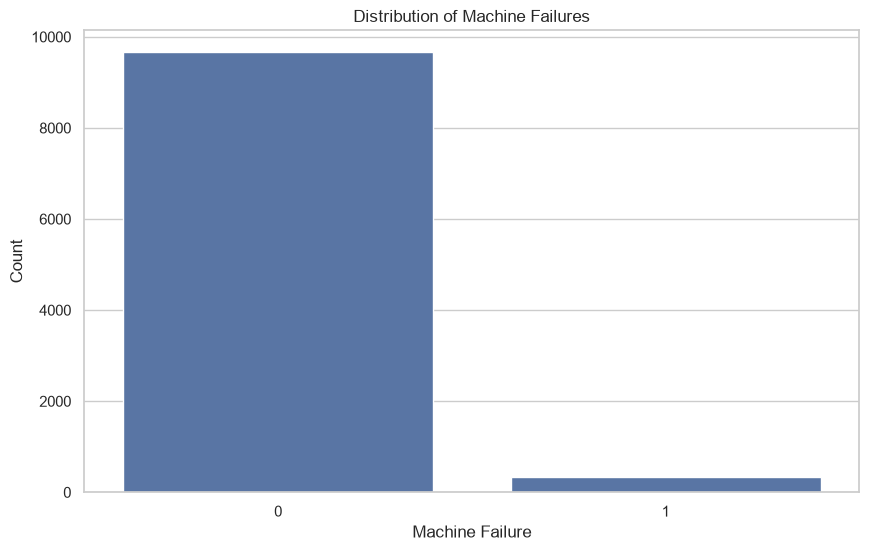

In [23]:
sns.countplot(data=df, x="Machine_failure")

plt.title("Distribution of Machine Failures")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

### 6.2 Distribution of Machine Types

In [24]:
df[["Type_L", "Type_M"]].sum()

Type_L    6000
Type_M    2997
dtype: int64

In [25]:
df_eda = df.copy()

df_eda["Machine Type"] = "H"
df_eda.loc[df_eda["Type_L"] == 1, "Machine Type"] = "L"
df_eda.loc[df_eda["Type_M"] == 1, "Machine Type"] = "M"

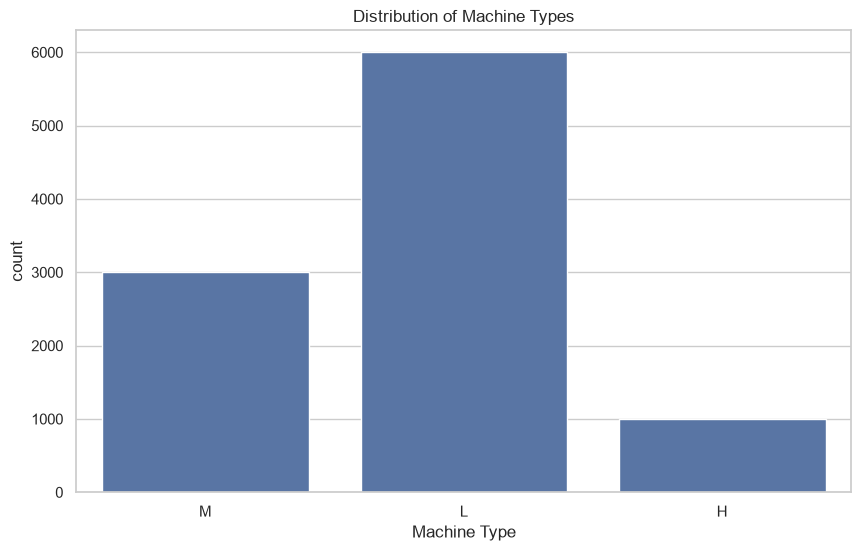

In [26]:
sns.countplot(data=df_eda, x="Machine Type")

plt.title("Distribution of Machine Types")
plt.show()

### 6.3 Distribution of Numerical Features

In [27]:
numerical_features = [
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min"
]

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


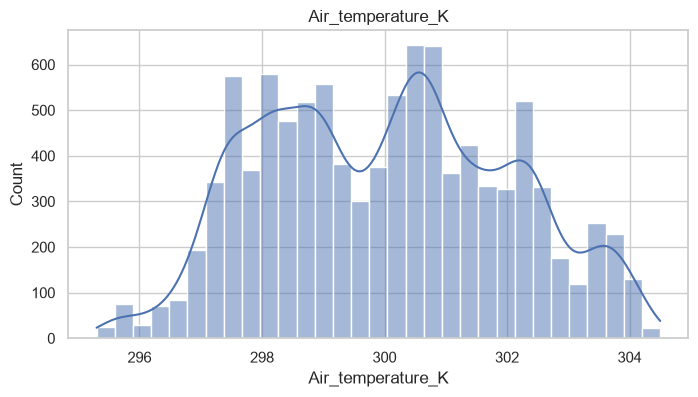

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


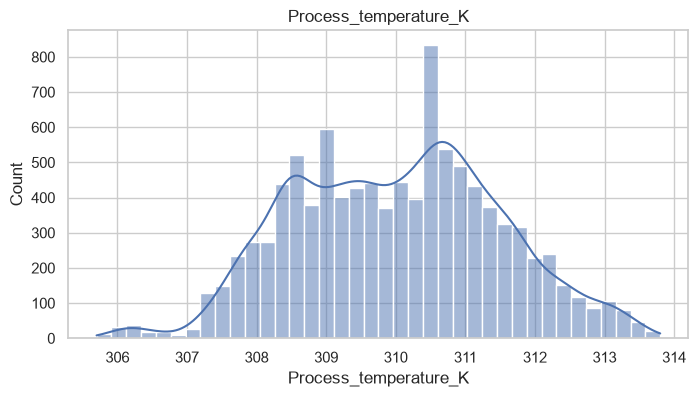

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


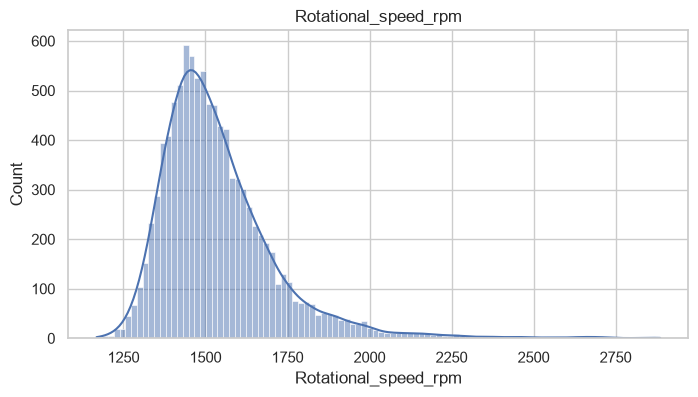

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


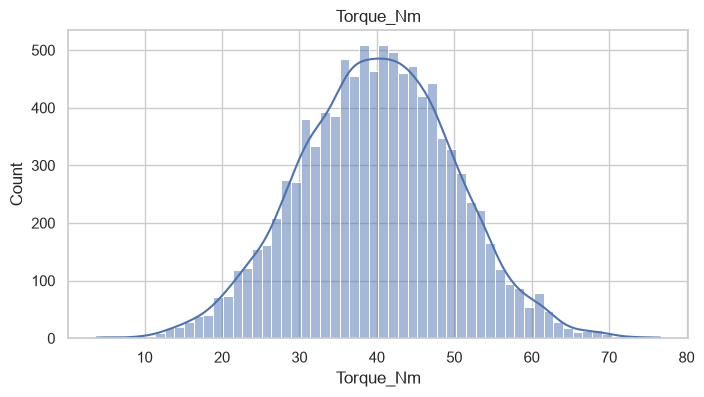

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


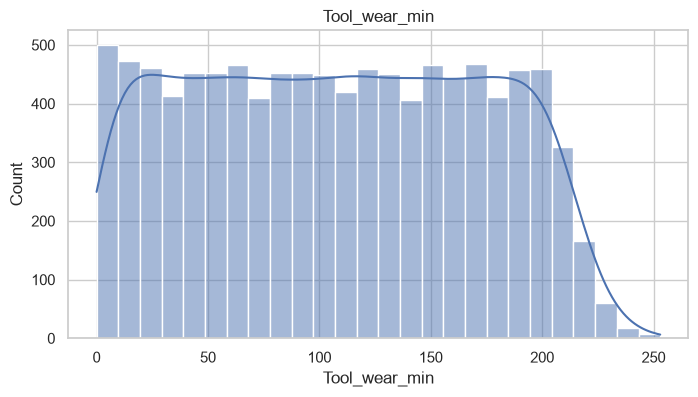

In [28]:
for feature in numerical_features:
    plt.figure(figsize=(8,4))

    sns.histplot(df[feature], kde=True)

    plt.title(feature)

    plt.show()

### 6.4 Outliers

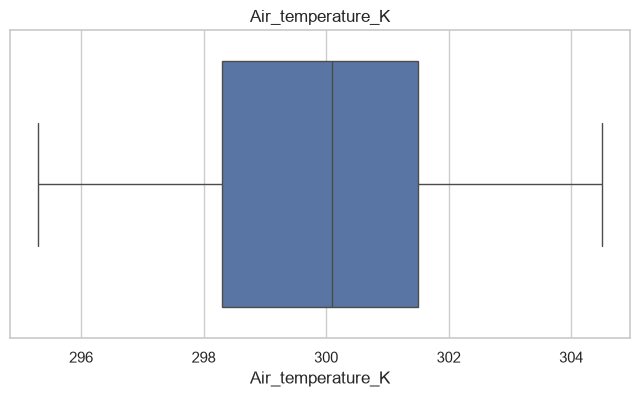

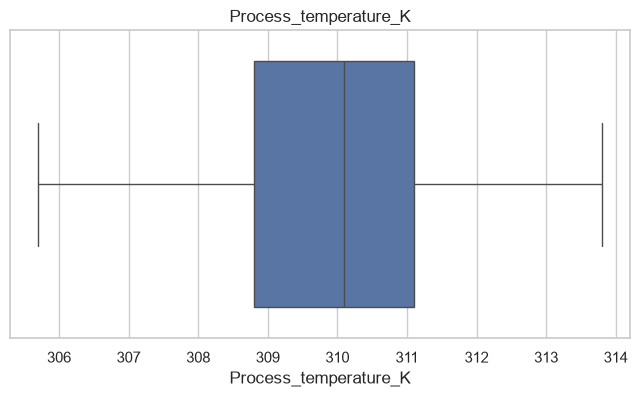

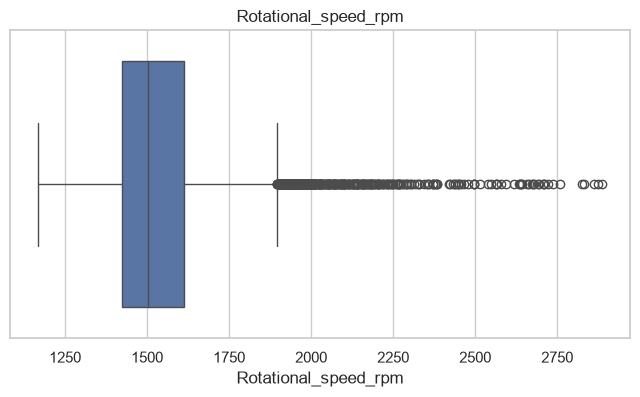

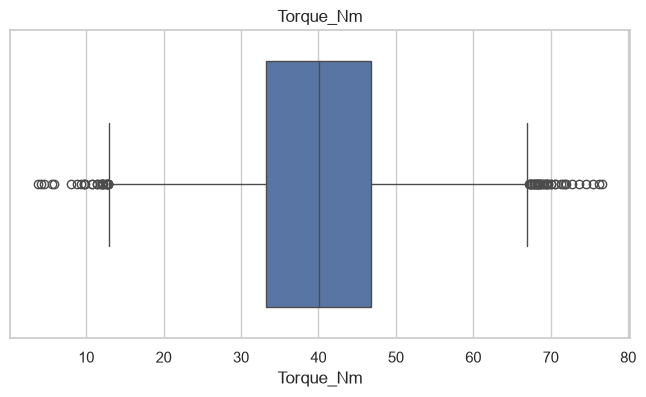

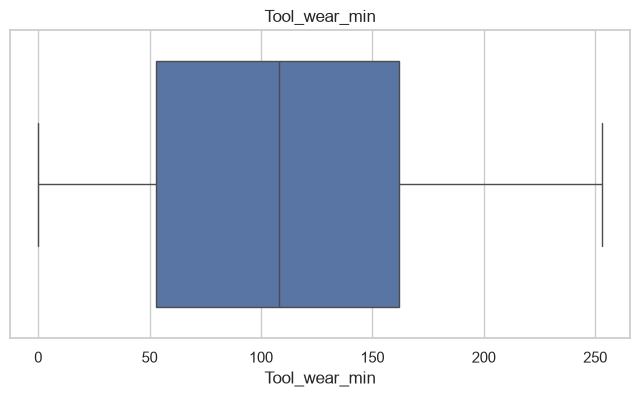

In [29]:
for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[feature])

    plt.title(feature)

    plt.show()

### 6.5 Correlation

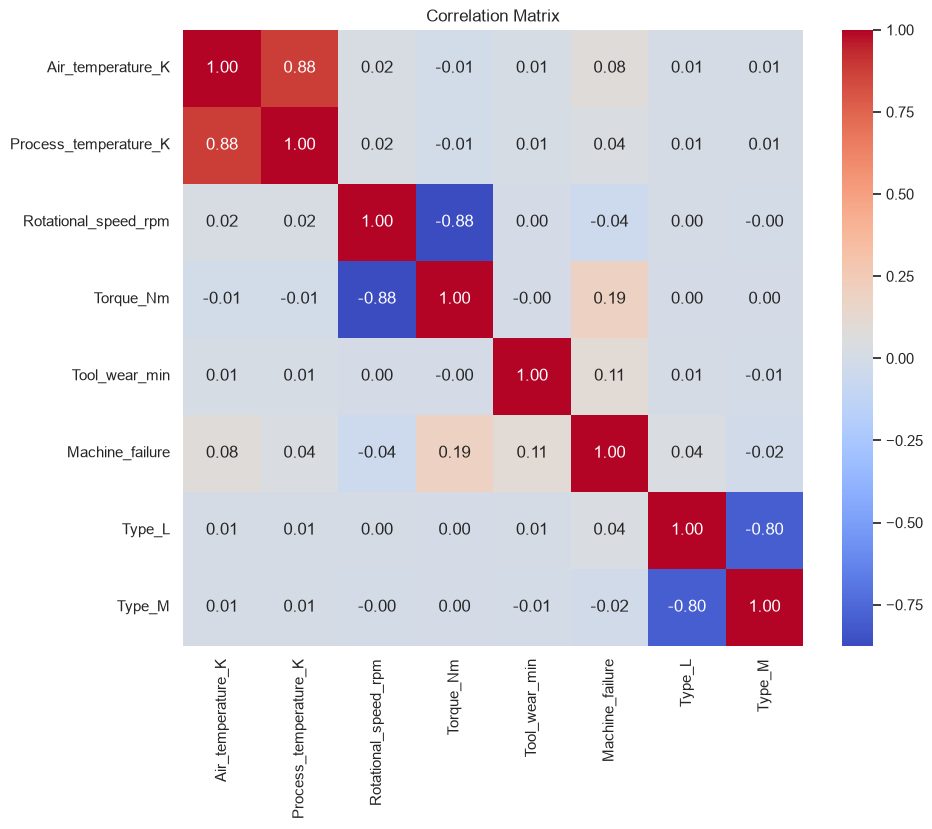

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### 6.6 Features of Failed and Non-Failed Machines

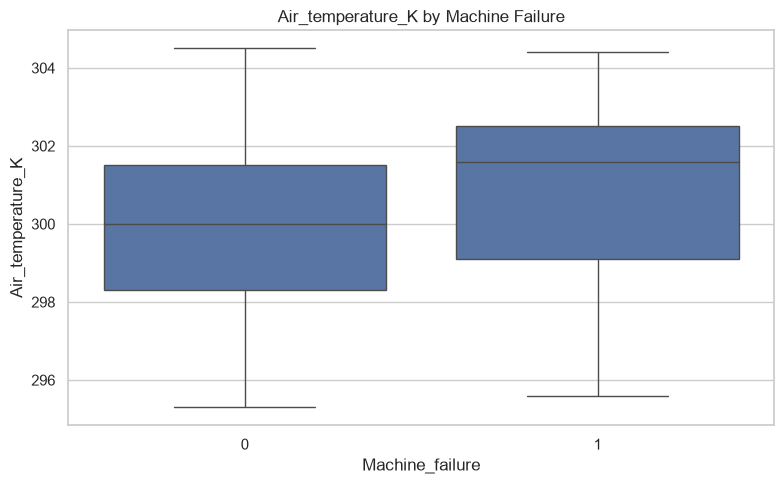

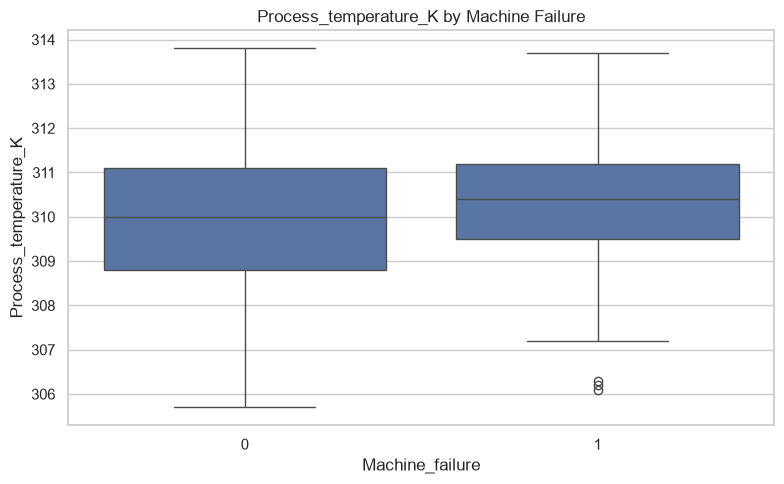

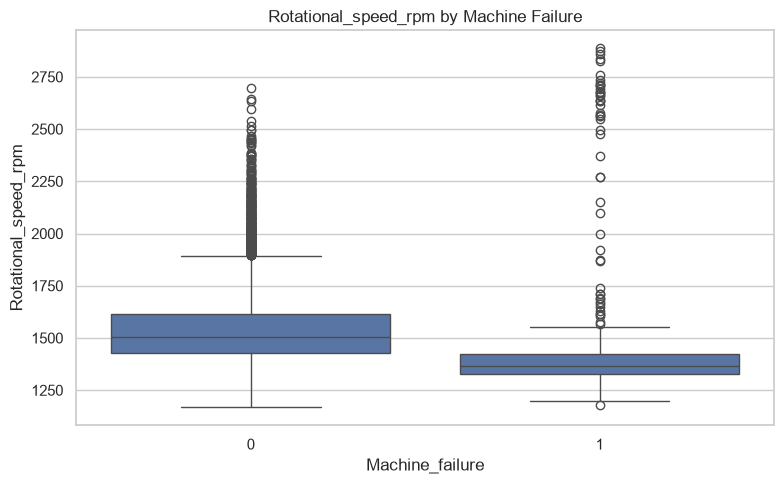

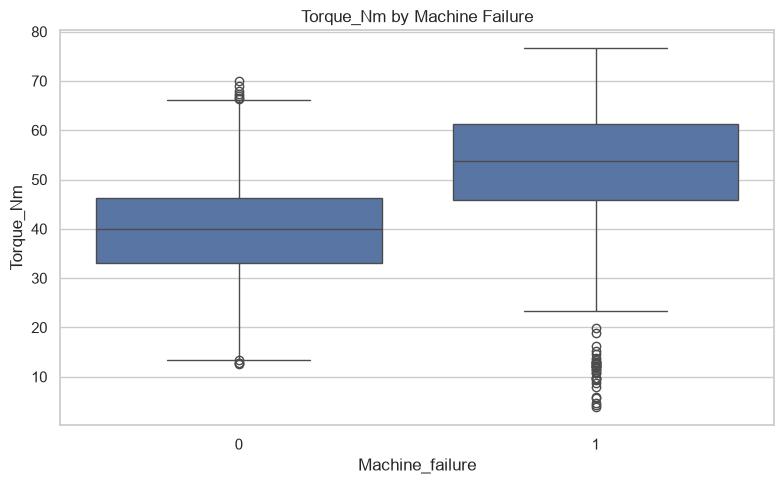

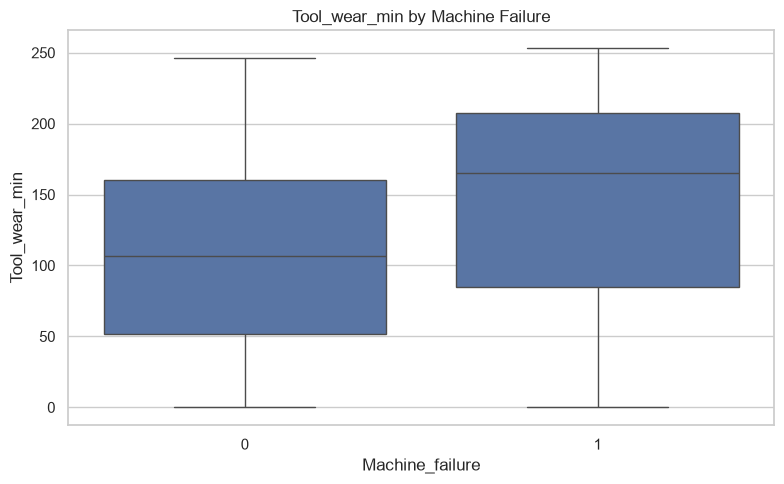

In [31]:
features = [
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min"
]

for feature in features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Machine_failure",
        y=feature
    )

    plt.title(f"{feature} by Machine Failure")
    plt.tight_layout()
    plt.show()

### 6.7 Summary of Exploratory Data Analysis

The exploratory data analysis identified several important characteristics of the dataset. Machine failures are relatively rare, resulting in an imbalanced classification problem. Additionally, the machine types are not evenly distributed, with Type L representing the largest proportion of observations.

The numerical variables exhibit different distributions. Air temperature, process temperature, and torque are approximately normally distributed, while rotational speed is positively skewed. The boxplots show that machines experiencing failures generally operate at higher air and process temperatures, higher torque, greater tool wear, and lower rotational speeds than machines without failures.

The correlation matrix reveals strong relationships between air temperature and process temperature (0.88) and between rotational speed and torque (-0.88). However, the target variable shows only weak linear correlations with the individual features. Together with the boxplots, this suggests that machine failures are influenced by combinations of operating conditions rather than a single variable, making the dataset well suited for machine learning models that can learn complex, non-linear relationships.

## 7. Machine Learning Preparation
### 7.1 Load Processed Dataset


In [32]:
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "ai4i2020_processed.csv")

### 7.2 Feature / Target Split

In [33]:
X = df.drop(columns=["Machine_failure"])
y = df["Machine_failure"]

### 7.3 Train / Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.to_csv(
    PROJECT_ROOT / "data" / "processed" / "X_train.csv", 
    index=False)
X_test.to_csv(
    PROJECT_ROOT / "data" / "processed" / "X_test.csv", 
    index=False)

y_train.to_csv(
    PROJECT_ROOT / "data" / "processed" / "y_train.csv", 
               index=False)
y_test.to_csv(
    PROJECT_ROOT / "data" / "processed" / "y_test.csv", 
    index=False)

print("Train/test split saved.")

Train/test split saved.


## 8. Unsupervised Learning

Unlike supervised learning, unsupervised learning does not use a target variable. Instead, it is used to discover hidden patterns and relationships within the data. In this project, K-Means clustering is used to identify groups of machines with similar operating characteristics, while PCA and UMAP are used to visualize these clusters in two dimensions.

### 8.1 K-means Clustering

In [35]:
# Load the training data
X_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "X_train.csv")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Calculate inertia for k = 1 to 10
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sampl

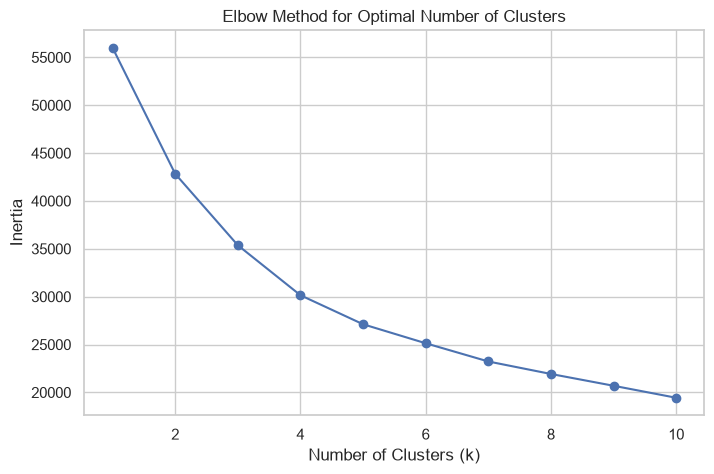

In [36]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

In [37]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_train_scaled)

X_train_clusters = X_train.copy()

X_train_clusters["Cluster"] = clusters

X_train_clusters.groupby("Cluster").mean()

X_train_clusters["Machine failure"] = y_train.values

pd.crosstab(
    X_train_clusters["Cluster"],
    X_train_clusters["Machine failure"]
)

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sampl

Machine failure,0,1
Cluster,,
0,2323,58
1,2754,69
2,2652,144


In [38]:
from sklearn.metrics import silhouette_score
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_scaled)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sampl

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sampl

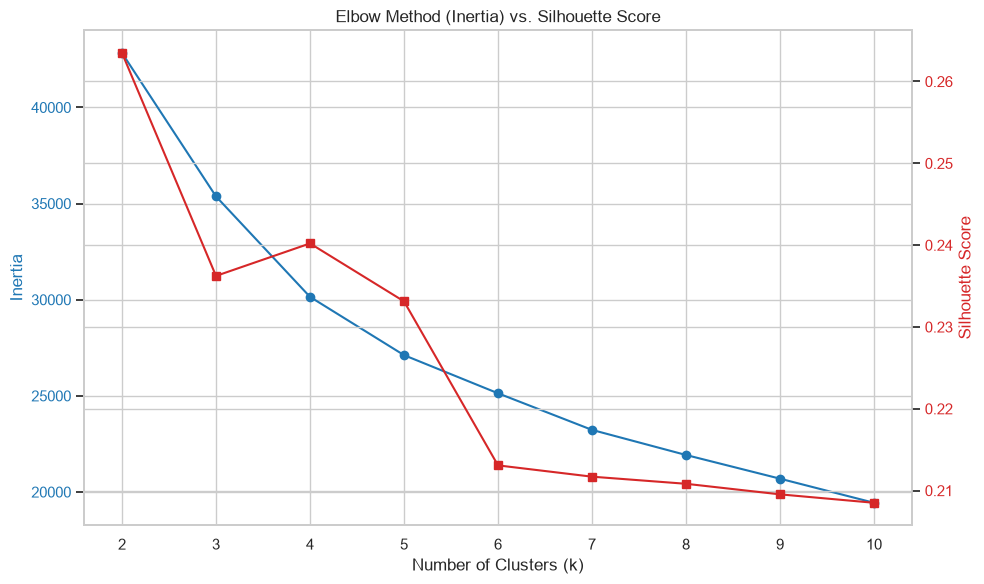

k=2: silhouette=0.2635
k=3: silhouette=0.2362
k=4: silhouette=0.2402
k=5: silhouette=0.2331
k=6: silhouette=0.2131
k=7: silhouette=0.2117
k=8: silhouette=0.2108
k=9: silhouette=0.2095
k=10: silhouette=0.2085


In [39]:
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []

k_range = range(2, 11)  # silhouette needs k >= 2

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_train_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color=color1)
ax1.plot(list(k_range), inertia, marker="o", color=color1, label="Inertia")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color2)
ax2.plot(list(k_range), sil_scores, marker="s", color=color2, label="Silhouette Score")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Elbow Method (Inertia) vs. Silhouette Score")
fig.tight_layout()
plt.show()

for k, sil in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={sil:.4f}")

### 8.2 PCA
Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms high-dimensional data into a smaller number of components while preserving as much of the original variation as possible. In this project, PCA is used to visualize the clusters identified by the K-Means algorithm in two dimensions.

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


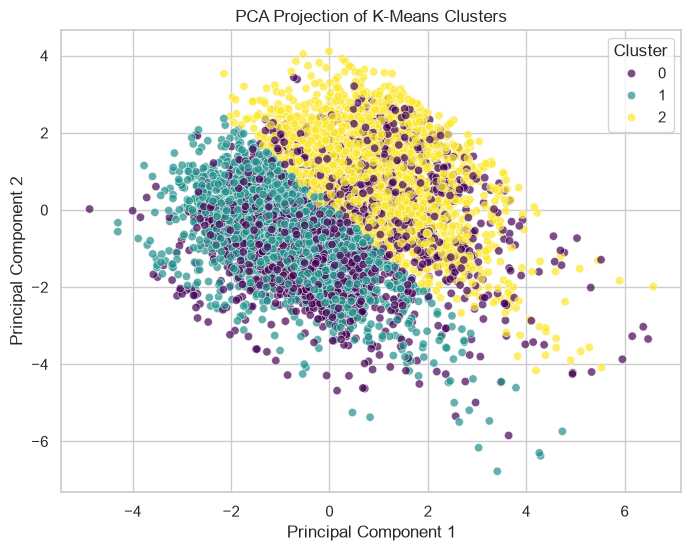

Explained variance: 53.60%


In [40]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("PCA Projection of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

print(
    f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}"
)


PCA reduced the seven-dimensional feature space to two principal components while retaining **53.6%** of the total variance. This made it possible to visualize the K-Means clusters in two dimensions.

The projection shows moderate separation between the clusters, with Cluster 2 appearing more distinct than Clusters 0 and 1, which exhibit greater overlap. This suggests that while the first two principal components capture much of the dataset's structure, some information is inevitably lost during dimensionality reduction. Overall, the PCA visualization supports the presence of meaningful underlying patterns in the data.

### 8.3 UMAP

/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


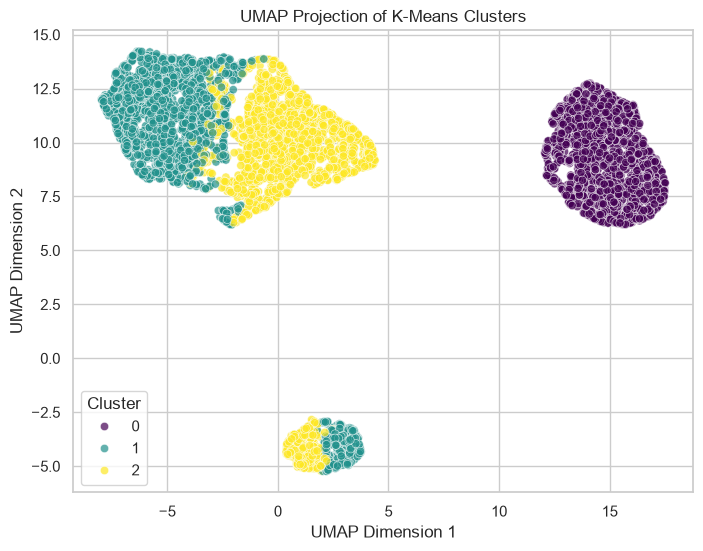

In [41]:
reducer = umap.UMAP(random_state=42)

X_umap = reducer.fit_transform(X_train_scaled)

umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)

umap_df["Cluster"] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("UMAP Projection of K-Means Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.legend(title="Cluster")

plt.show()

UMAP provided a clearer visualization of the K-Means clusters than PCA by preserving the local structure of the data. Cluster 0 is almost completely separated from the remaining clusters, while Clusters 1 and 2 exhibit less overlap than in the PCA projection.

The improved separation suggests that the dataset contains meaningful non-linear relationships that are not fully captured by PCA. These results further support the presence of distinct operating profiles within the data and demonstrate the value of modern dimensionality reduction techniques for exploring complex industrial datasets.

### 8.4 Summary

The optimal number of clusters was evaluated using both the Elbow Method and the Silhouette Score. Although the silhouette score was highest for **k = 2**, a three-cluster solution was selected because it provided more interpretable operating profiles and revealed a distinct group of machines with a substantially higher failure rate.

K-Means successfully identified three operating profiles without using the machine failure labels. Cluster 2 exhibited a failure rate of **5.15%**, compared with **2.44%** for Clusters 0 and 1. PCA and UMAP both visualized these clusters, with UMAP providing clearer separation by preserving non-linear relationships in the data. Together, these results demonstrate that the dataset contains meaningful underlying structure and provide a strong foundation for the supervised machine learning models developed in the next section.

## 9. Supervised Learning

Unlike the previous section, supervised learning uses historical machine failure labels to train models that can predict whether a machine is likely to fail. Several algorithms are evaluated and compared to determine which model provides the best predictive performance for industrial maintenance applications.

### 9.1 Logistic Regression (Baseline Model)
Logistic Regression is used as a baseline classification model. Although it assumes a linear relationship between the input features and the target variable, it provides a useful benchmark against which more complex machine learning models can be compared.

In [42]:
# Load the saved train/test split
X_train = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "X_train.csv"
)
X_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "X_test.csv"
    )

y_train = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "y_train.csv"
    ).squeeze()
y_test = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "y_test.csv"
                     ).squeeze()

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_path = MODEL_DIR / "logistic_regression.pkl"

if log_reg_path.exists():
    print("Loading Logistic Regression model...")
    log_reg = joblib.load(log_reg_path)
else:
    print("Training Logistic Regression model...")

    log_reg = LogisticRegression(random_state=42)

    log_reg.fit(X_train_scaled, y_train)

    joblib.dump(log_reg, log_reg_path)

y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

Loading Logistic Regression model...


/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victoria/dev/aikurs/industrial-maintenance-project/.venv

### 9.2 Random Forest
Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. Unlike Logistic Regression, Random Forest can capture complex, non-linear relationships between the predictor variables and the target variable.

In [43]:
rf_path = MODEL_DIR / "random_forest.pkl"

if rf_path.exists():
    print("Loading Random Forest model...")
    rf = joblib.load(rf_path)
else:
    print("Training Random Forest model...")

    rf = RandomForestClassifier(
        random_state=42
    )

    rf.fit(X_train, y_train)

    joblib.dump(rf, rf_path)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

Loading Random Forest model...


### 9.3 XGBoost
Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm that builds decision trees sequentially, with each tree improving upon the errors of the previous one. It is widely used in industrial machine learning applications because of its high predictive performance and ability to model complex, non-linear relationships.

In [44]:
xgb_path = MODEL_DIR / "xgboost.pkl"

if xgb_path.exists():
    print("Loading XGBoost model...")
    xgb = joblib.load(xgb_path)
else:
    print("Training XGBoost model...")

    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )

    xgb.fit(X_train, y_train)

    joblib.dump(xgb, xgb_path)

# Predict the test set

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

Loading XGBoost model...


### 9.4 Artificial Neural Network (ANN)

Artificial Neural Networks (ANNs) are deep learning models capable of learning complex, non-linear relationships between input features and the target variable. In this project, a feedforward neural network is trained to predict machine failures and compared with the traditional machine learning models.

In [45]:
# Load the saved train/test split
X_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "X_train.csv")
X_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "X_test.csv")

y_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "y_train.csv").squeeze()
y_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "y_test.csv").squeeze()

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert for TensorFlow
X_train_nn = X_train_scaled.astype(np.float32)
X_test_nn = X_test_scaled.astype(np.float32)

y_train_nn = y_train.astype(np.float32)
y_test_nn = y_test.astype(np.float32)

In [46]:
# ===========================
# Artificial Neural Network
# ===========================

ann_path = MODEL_DIR / "neural_network.keras"
history_path = MODEL_DIR / "neural_network_history.csv"

if ann_path.exists():
    print("Loading Neural Network...")
    model = tf.keras.models.load_model(ann_path)

else:
    print("Training Neural Network...")

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_nn.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_nn,
        y_train_nn,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=2
    )

    print("Saving Neural Network...")
    model.save(ann_path)

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(history_path, index=False)

    print(f"Model saved to: {ann_path}")
    print(f"History saved to: {history_path}")

Training Neural Network...
Epoch 1/100
200/200 - 0s - 1ms/step - accuracy: 0.6130 - loss: 0.6451 - val_accuracy: 0.9644 - val_loss: 0.3629
Epoch 2/100
200/200 - 0s - 410us/step - accuracy: 0.9663 - loss: 0.2627 - val_accuracy: 0.9656 - val_loss: 0.1951
Epoch 3/100
200/200 - 0s - 395us/step - accuracy: 0.9663 - loss: 0.1744 - val_accuracy: 0.9656 - val_loss: 0.1575
Epoch 4/100
200/200 - 0s - 402us/step - accuracy: 0.9663 - loss: 0.1492 - val_accuracy: 0.9656 - val_loss: 0.1427
Epoch 5/100
200/200 - 0s - 402us/step - accuracy: 0.9663 - loss: 0.1357 - val_accuracy: 0.9656 - val_loss: 0.1325
Epoch 6/100
200/200 - 0s - 400us/step - accuracy: 0.9663 - loss: 0.1255 - val_accuracy: 0.9656 - val_loss: 0.1246
Epoch 7/100
200/200 - 0s - 394us/step - accuracy: 0.9663 - loss: 0.1171 - val_accuracy: 0.9656 - val_loss: 0.1176
Epoch 8/100
200/200 - 0s - 390us/step - accuracy: 0.9667 - loss: 0.1103 - val_accuracy: 0.9669 - val_loss: 0.1121
Epoch 9/100
200/200 - 0s - 393us/step - accuracy: 0.9677 - loss

In [47]:
y_prob_ann = model.predict(X_test_nn).flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step


## 10. Model Evaluation

### 10.1. Logistic Regression Evaluation
Logistic Regression was evaluated on the test dataset to assess its ability to predict machine failures. Performance was measured using accuracy, precision, recall, F1-score, ROC-AUC, a confusion matrix, and a classification report, providing a comprehensive assessment of the model's classification performance.

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

Accuracy : 0.9675
Precision: 0.6364
Recall   : 0.1029
F1-score : 0.1772
ROC-AUC  : 0.8995


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



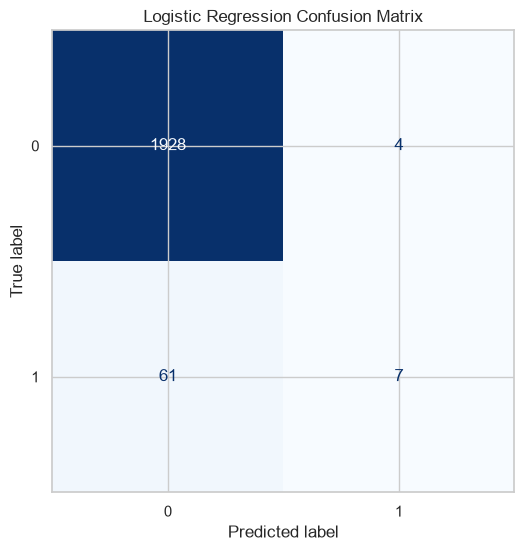

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues",
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

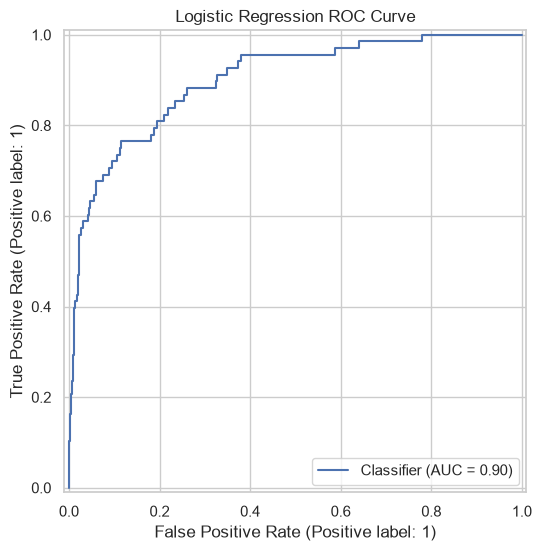

In [51]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("Logistic Regression ROC Curve")
plt.show()

Logistic Regression achieved a high overall accuracy (96.75%) and an excellent ROC-AUC score (0.90), indicating good discrimination between normal and failure cases. However, the model detected only a small proportion of actual machine failures, resulting in a low recall (10.3%). This outcome is likely influenced by the strong class imbalance in the dataset, where failure cases are relatively rare. 

While Logistic Regression provides a simple, interpretable, and computationally efficient baseline model, its low recall limits its suitability for predictive maintenance, where failing to identify an impending machine failure can result in costly unplanned downtime. More advanced models are therefore explored in the following sections to improve failure detection.

### 10.2 Random Forest Evaluation
The Random Forest classifier was evaluated using the same performance metrics as Logistic Regression to assess its ability to detect machine failures. In addition, feature importance was examined to identify which variables contributed most to the model's predictions.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.9820
Precision: 0.8810
Recall   : 0.5441
F1-score : 0.6727
ROC-AUC  : 0.9616


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.54      0.67        68

    accuracy                           0.98      2000
   macro avg       0.93      0.77      0.83      2000
weighted avg       0.98      0.98      0.98      2000



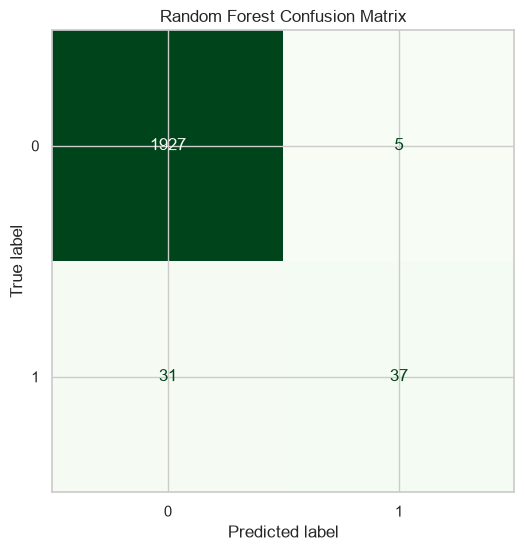

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens",
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")
plt.show()

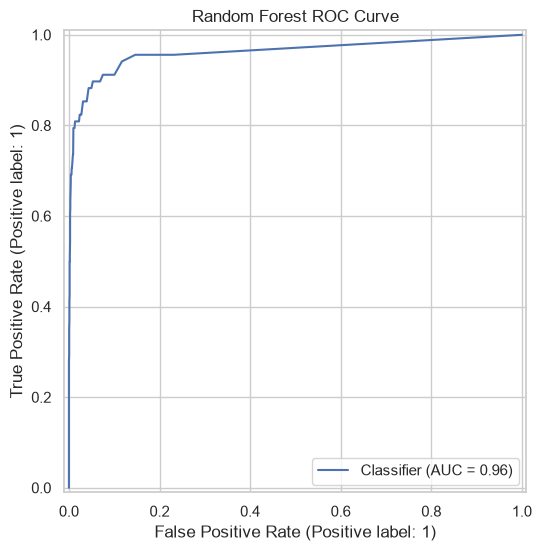

In [55]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest ROC Curve")
plt.show()

In [56]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
3,Torque_Nm,0.325825
2,Rotational_speed_rpm,0.227352
4,Tool_wear_min,0.169995
0,Air_temperature_K,0.133897
1,Process_temperature_K,0.116458
5,Type_L,0.016400
6,Type_M,0.010072


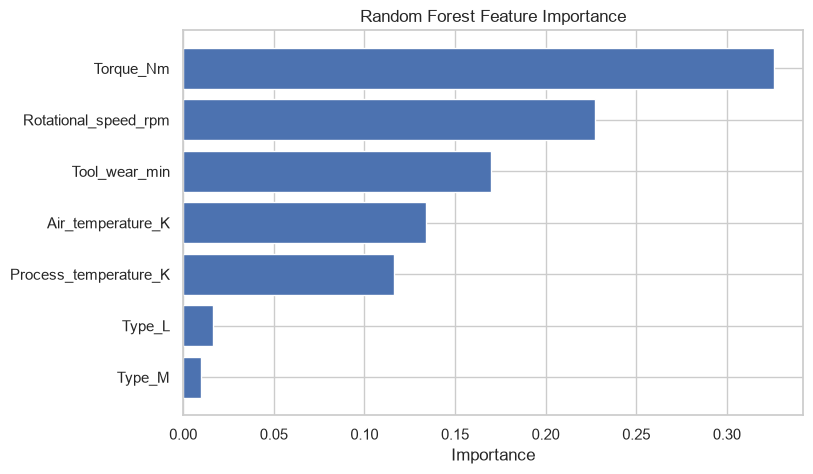

In [57]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

The Random Forest classifier achieved strong predictive performance, outperforming Logistic Regression across all evaluation metrics. It obtained an accuracy of 98.20% and an ROC-AUC score of 0.96, while increasing recall from 10.3% to 54.4%. This represents a substantial improvement in detecting machine failures, identifying 37 of the 68 failure cases while maintaining a high precision of 88.1% and only five false positives. 

Feature importance analysis indicates that torque, rotational speed, and tool wear were the most influential predictors of machine failure, which is consistent with engineering expectations for predictive maintenance. Overall, the Random Forest model demonstrates a strong balance between predictive performance and interpretability, making it a suitable candidate for industrial decision support applications.

### 10.3 XGBoost Evaluation

The XGBoost classifier was evaluated using the same performance metrics as the previous models to assess its ability to predict machine failures. As a gradient boosting algorithm, XGBoost often achieves high predictive performance while providing feature importance scores that help explain the model's predictions.

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

Accuracy : 0.9870
Precision: 0.9200
Recall   : 0.6765
F1-score : 0.7797
ROC-AUC  : 0.9770


In [59]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



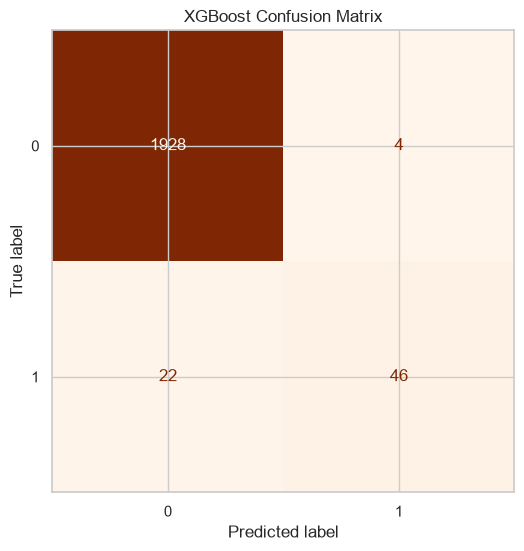

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Oranges",
    colorbar=False
)

plt.title("XGBoost Confusion Matrix")
plt.show()

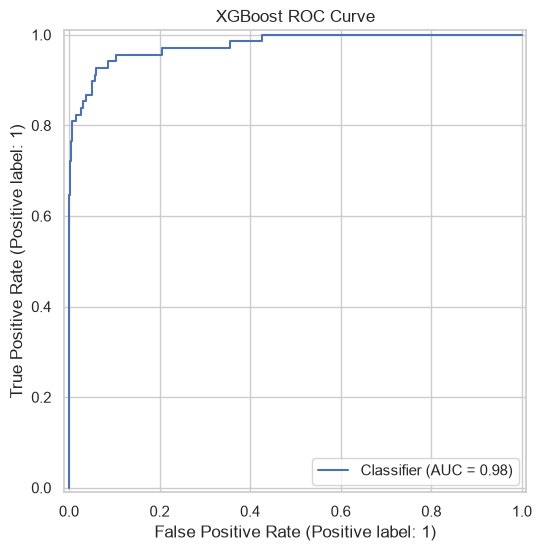

In [61]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost ROC Curve")
plt.show()

In [62]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_xgb)

feature_importance_xgb.to_csv(
    MODEL_DIR / "feature_importance.csv",
    index=False
)

,Feature,Importance
3,Torque_Nm,0.279560
2,Rotational_speed_rpm,0.187220
4,Tool_wear_min,0.167318
0,Air_temperature_K,0.145185
1,Process_temperature_K,0.088657
6,Type_M,0.070066
5,Type_L,0.061994


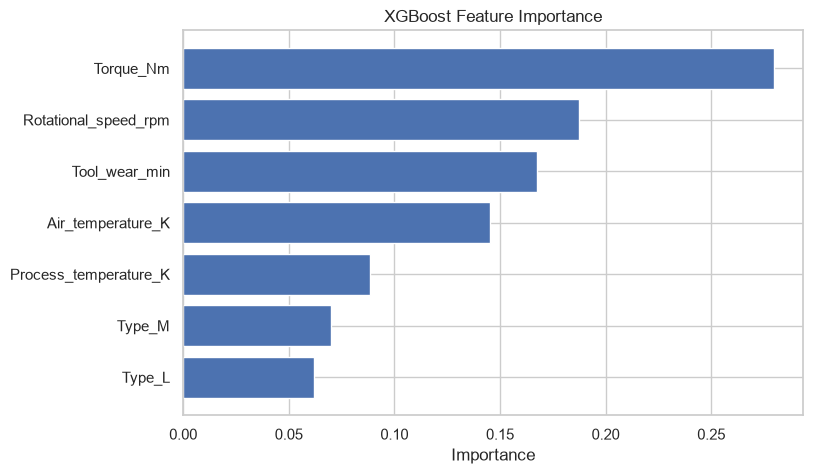

In [63]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_xgb["Feature"],
    feature_importance_xgb["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

The XGBoost classifier achieved the best predictive performance of all models evaluated thus far, with an accuracy of 98.70% and an ROC-AUC score of 0.98. Compared with Random Forest, XGBoost further improved recall from 54.4% to 67.6%, successfully identifying 46 of the 68 machine failures while maintaining a high precision of 92.0%. This resulted in the highest F1-score (0.78), indicating a strong balance between precision and recall. 

Feature importance analysis identified torque, rotational speed, and tool wear as the most influential predictors of machine failure, consistent with the findings from the Random Forest model. Overall, XGBoost demonstrated the strongest predictive capability and appears to be the most suitable model for predictive maintenance among the tree-based approaches evaluated in this project.

### 10.4 Artificial Neural Network (ANN) Evaluation

The Artificial Neural Network (ANN) was evaluated using the same classification metrics as the previous supervised learning models. In addition, the training history was analyzed to assess the model's learning behavior and identify potential signs of overfitting or underfitting.

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_prob_ann)

print(f"Accuracy : {ann_accuracy:.4f}")
print(f"Precision: {ann_precision:.4f}")
print(f"Recall   : {ann_recall:.4f}")
print(f"F1-score : {ann_f1:.4f}")
print(f"ROC-AUC  : {ann_auc:.4f}")

Accuracy : 0.9760
Precision: 0.7941
Recall   : 0.3971
F1-score : 0.5294
ROC-AUC  : 0.9657


In [65]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.79      0.40      0.53        68

    accuracy                           0.98      2000
   macro avg       0.89      0.70      0.76      2000
weighted avg       0.97      0.98      0.97      2000



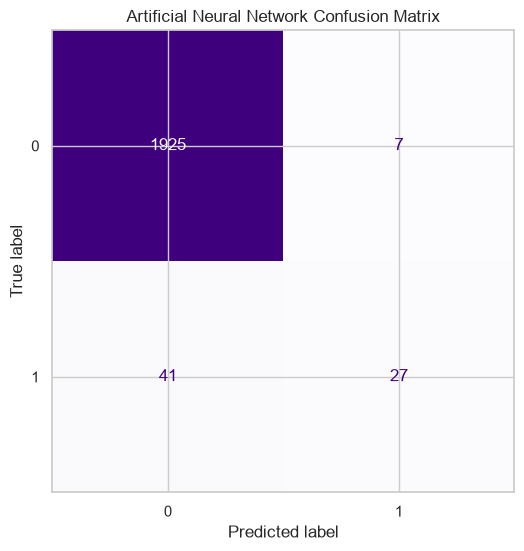

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ann,
    cmap="Purples",
    colorbar=False
)

plt.title("Artificial Neural Network Confusion Matrix")
plt.show()

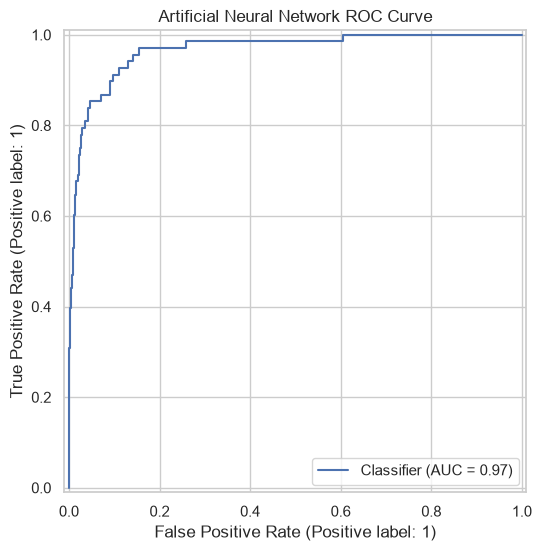

In [67]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_ann
)

plt.title("Artificial Neural Network ROC Curve")
plt.show()

In [68]:
history_df = pd.read_csv(history_path)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.612969,0.645055,0.964375,0.362919
1,0.966250,0.262740,0.965625,0.195130
2,0.966250,0.174392,0.965625,0.157486
3,0.966250,0.149240,0.965625,0.142651
4,0.966250,0.135740,0.965625,0.132526


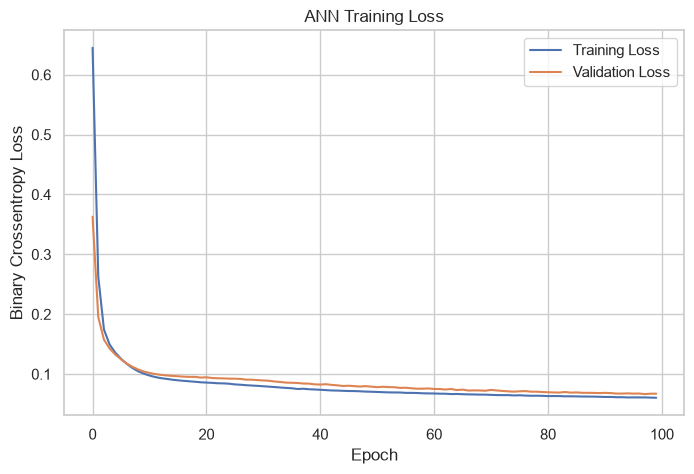

In [69]:
plt.figure(figsize=(8,5))

plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("ANN Training Loss")

plt.legend()

plt.show()

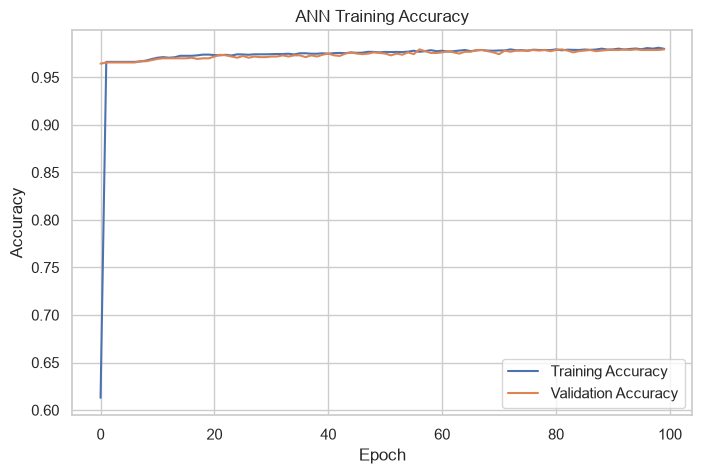

In [70]:
plt.figure(figsize=(8,5))

plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training Accuracy")

plt.legend()

plt.show()

The Artificial Neural Network achieved an accuracy of 97.35% and an ROC-AUC score of 0.96, demonstrating good predictive performance on the machine failure dataset. 

The model improved substantially over the Logistic Regression baseline but did not outperform the tree-based ensemble models, particularly XGBoost, in terms of recall and F1-score. 

The training and validation loss curves decreased smoothly and remained closely aligned throughout training, while the accuracy curves converged at approximately 97–98%, indicating stable learning without significant overfitting. 

Overall, the ANN successfully captured nonlinear relationships within the data and provides a strong deep learning baseline for comparison, although XGBoost achieved the best overall balance between precision, recall, and classification performance.

### 10.5 Model Comparison
The supervised learning models were compared using the same evaluation metrics to determine which algorithm provided the best balance between predictive performance and machine failure detection. Particular emphasis was placed on recall and F1-score, as correctly identifying machine failures is more important than maximizing overall accuracy in predictive maintenance applications.

In [71]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        ann_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision,
        ann_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall,
        ann_recall
    ],
    "F1-score": [
        lr_f1,
        rf_f1,
        xgb_f1,
        ann_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc,
        ann_auc
    ]
})

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995
1,Random Forest,0.9820,0.8810,0.5441,0.6727,0.9616
2,XGBoost,0.9870,0.9200,0.6765,0.7797,0.9770
3,Artificial Neural Network,0.9760,0.7941,0.3971,0.5294,0.9657


In [72]:
comparison.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.967500,0.636400,0.102900,0.177200,0.899500
1,Random Forest,0.982000,0.881000,0.544100,0.672700,0.961600
2,XGBoost,0.987000,0.920000,0.676500,0.779700,0.977000
3,Artificial Neural Network,0.976000,0.794100,0.397100,0.529400,0.965700


<Figure size 1000x600 with 0 Axes>

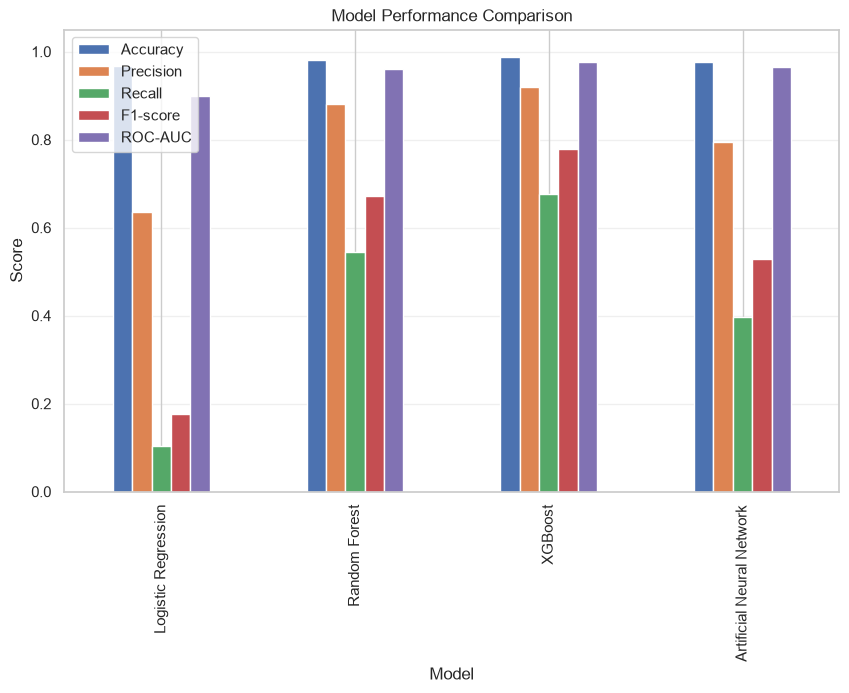

In [73]:
metrics = comparison.set_index("Model")

plt.figure(figsize=(10,6))

metrics.plot(kind="bar")

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Model Performance Comparison")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [74]:
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,XGBoost,0.9870,0.9200,0.6765,0.7797,0.9770
3,Artificial Neural Network,0.9760,0.7941,0.3971,0.5294,0.9657
1,Random Forest,0.9820,0.8810,0.5441,0.6727,0.9616
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995


**Interpretation**

The supervised learning models demonstrated varying levels of predictive performance on the predictive maintenance dataset. Logistic Regression served as an effective baseline but achieved the lowest recall (10.3%), indicating that many machine failures were missed despite high overall accuracy. The Artificial Neural Network improved failure detection by learning nonlinear relationships in the data, but it did not outperform the tree-based ensemble methods.

Random Forest achieved a substantial improvement in recall and F1-score while maintaining high precision, demonstrating that ensemble learning is well suited to predictive maintenance problems. XGBoost achieved the highest performance across all evaluation metrics, with an accuracy of 98.70%, precision of 92.0%, recall of 67.6%, F1-score of 0.78, and ROC-AUC of 0.98. These results indicate that XGBoost was the most effective model at correctly identifying machine failures while minimizing false alarms.

Based on the overall evaluation, XGBoost was selected as the final model for the predictive maintenance decision support system. Its strong predictive performance and balanced classification metrics make it well suited for deployment in industrial maintenance applications.

These findings are supported by [Alnahhal et al. (2026)](https://www.mdpi.com/2079-3197/14/4/88), who evaluated multiple machine learning algorithms on the AI4I 2020 Predictive Maintenance dataset. Their study reported that XGBoost achieved the highest macro-F1 score among the evaluated models, demonstrating superior predictive performance compared with Random Forest and Logistic Regression. The results of the present project similarly identify XGBoost as the strongest-performing model.

In [75]:
comparison.sort_values(
    by=["Recall", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.9870,0.9200,0.6765,0.7797,0.9770
1,Random Forest,0.9820,0.8810,0.5441,0.6727,0.9616
2,Artificial Neural Network,0.9760,0.7941,0.3971,0.5294,0.9657
3,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8995


## 11. AI Decision Support System

### 11.1 Introduction
The objective of predictive maintenance is not only to predict machine failures but also to support maintenance planning and operational decision-making. Based on the model evaluation presented in Chapter 10, XGBoost was selected as the final predictive model due to its superior performance across all evaluation metrics. This section demonstrates how the model's predictions can be transformed into actionable maintenance recommendations through a simple decision support system.

### 11.2 Predict Failure Probability

In [76]:
# Predict failure probabilities

failure_probability = xgb.predict_proba(X_test)[:, 1]

decision_support = X_test.copy()

# Keep the raw probability for calculations
decision_support["Failure Probability"] = failure_probability

decision_support["Predicted Failure"] = y_pred_xgb

decision_support["Predicted Failure"] = (
    decision_support["Predicted Failure"]
    .map({0: "No", 1: "Yes"})
)

# Display version as a percentage
decision_support["Failure Probability (%)"] = (
    decision_support["Failure Probability"] * 100
).round(2)

decision_support.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M,Failure Probability,Predicted Failure,Failure Probability (%)
0,300.5,309.8,1345,62.7,153,1,0,0.071167,No,7.12
1,303.7,312.4,1513,40.1,135,1,0,0.000458,No,0.05
2,302.5,311.4,1559,37.6,209,1,0,0.037809,No,3.78
3,295.6,306.3,1509,35.8,60,0,0,0.000825,No,0.08
4,300.5,310.0,1358,60.4,102,0,0,0.011242,No,1.12


### 11.3 Risk Classification
ndustrial systems rarely use only "Failure / No Failure."

Instead they classify risk.

Example

In [77]:
def risk_level(prob):

    if prob >= 0.80:
        return "Critical"

    elif prob >= 0.60:
        return "High"

    elif prob >= 0.30:
        return "Medium"

    else:
        return "Low"

decision_support["Risk Level"] = decision_support["Failure Probability"].apply(risk_level)

decision_support.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M,Failure Probability,Predicted Failure,Failure Probability (%),Risk Level
0,300.5,309.8,1345,62.7,153,1,0,0.071167,No,7.12,Low
1,303.7,312.4,1513,40.1,135,1,0,0.000458,No,0.05,Low
2,302.5,311.4,1559,37.6,209,1,0,0.037809,No,3.78,Low
3,295.6,306.3,1509,35.8,60,0,0,0.000825,No,0.08,Low
4,300.5,310.0,1358,60.4,102,0,0,0.011242,No,1.12,Low


### 11.4 Maintenance Priority
Converting risk into maintenance actions

In [78]:
priority_map = {
    "Critical": 1,
    "High": 2,
    "Medium": 3,
    "Low": 4
}

decision_support["Priority"] = (
    decision_support["Risk Level"]
    .map(priority_map)
)

### 11.5 Suggested Maintenance Action

In [79]:
def maintenance_action(level):

    if level == "Critical":
        return "Immediate maintenance"

    elif level == "High":
        return "Schedule maintenance within 24 hours"

    elif level == "Medium":
        return "Inspect during next maintenance window"

    else:
        return "Continue monitoring"

decision_support["Recommended Action"] = (
    decision_support["Risk Level"]
    .apply(maintenance_action)
)

decision_support = decision_support.rename(
    columns={"Priority": "Maintenance Priority"}
)

### 11.6 Maintenance Schedule
Sort by priority

In [80]:
decision_support = decision_support.sort_values(
    by=[
        "Maintenance Priority",
        "Failure Probability"
    ],
    ascending=[True, False]
)

decision_support_display = decision_support.copy()

decision_support_display["Failure Probability"] = (
    decision_support_display["Failure Probability"]
    .map(lambda x: f"{x:.2%}")
)

decision_support_display = decision_support_display[
    [
        "Failure Probability",
        "Predicted Failure",
        "Risk Level",
        "Maintenance Priority",
        "Recommended Action"
    ]
]

decision_support_display.head(20)

,Failure Probability,Predicted Failure,Risk Level,Maintenance Priority,Recommended Action
1225,98.71%,Yes,Critical,1,Immediate maintenance
1189,98.46%,Yes,Critical,1,Immediate maintenance
674,97.94%,Yes,Critical,1,Immediate maintenance
64,97.33%,Yes,Critical,1,Immediate maintenance
1517,96.87%,Yes,Critical,1,Immediate maintenance
1862,96.60%,Yes,Critical,1,Immediate maintenance
1745,96.05%,Yes,Critical,1,Immediate maintenance
1617,96.04%,Yes,Critical,1,Immediate maintenance
222,95.49%,Yes,Critical,1,Immediate maintenance
43,94.46%,Yes,Critical,1,Immediate maintenance


### 11.7 Interpretation

The XGBoost model was integrated into a decision support layer that transforms machine learning predictions into actionable maintenance decisions. 

Rather than returning only a binary failure prediction, the system estimates the probability of machine failure, classifies each machine according to its risk level, assigns a maintenance priority, and recommends an appropriate maintenance action. 

Sorting machines by predicted failure probability enables maintenance engineers to identify the most critical equipment and prioritize inspections before failures occur. This demonstrates how machine learning models can support proactive maintenance planning and more efficient allocation of maintenance resources.

## 12. Streamlit: Industrial AI Dashboard


### 12.1 Introduction
The machine learning models developed in this project demonstrate the ability to predict equipment failures using sensor measurements from the AI4I 2020 Predictive Maintenance dataset. While the notebook focuses on data preprocessing, model development, and evaluation, an operational system requires a user-friendly interface that allows maintenance engineers to interact with the model.

To bridge the gap between model development and practical application, a web-based dashboard was developed using Streamlit. The Industrial AI Maintenance Dashboard serves as a decision support system that enables users to view equipment risk levels, predict machine failures from new sensor data, and explore model performance through an interactive interface.

The dashboard is designed as a prototype of an AI-powered maintenance application that could be integrated with enterprise maintenance platforms such as SAP Plant Maintenance (SAP PM) or other Computerized Maintenance Management Systems (CMMS). Rather than replacing these systems, the dashboard demonstrates how machine learning predictions can support maintenance planning and decision-making in an industrial environment.

### 12.2 System Architecture

The overall workflow of the Industrial AI Maintenance Dashboard is illustrated below.

```text
                Sensor Data
                     │
                     ▼
            Data Preprocessing
                     │
                     ▼
              XGBoost Model
                     │
                     ▼
        Decision Support Engine
                     │
                     ▼
     Industrial AI Maintenance Dashboard
                     │
                     ▼
          Maintenance Engineer
```

The dashboard receives machine sensor measurements as input and applies the trained XGBoost model to estimate the probability of equipment failure. The prediction is then processed by a decision support layer, which converts model outputs into actionable information such as risk level, maintenance priority, and recommended actions. Finally, these results are presented through an interactive dashboard that enables maintenance engineers to prioritize inspections and maintenance activities.

### 12.3 Dashboard Overview

The Industrial AI Maintenance Dashboard was developed using Streamlit to demonstrate how the trained machine learning model can be deployed as an interactive decision support application. Rather than requiring users to interact directly with Python code or Jupyter notebooks, the dashboard provides an intuitive interface for maintenance engineers and decision-makers.

The application combines machine learning predictions with business-oriented visualizations, allowing users to assess equipment risk, prioritize maintenance activities, and explore model performance in a single interface. The dashboard is designed as a prototype of an industrial maintenance application that could be integrated into existing maintenance management systems such as SAP Plant Maintenance (SAP PM) or other Computerized Maintenance Management Systems (CMMS).

The dashboard consists of four primary pages:

- **Dashboard:** Displays key performance indicators (KPIs), equipment risk summaries, and high-priority maintenance recommendations.
- **Predict:** Allows users to enter machine sensor values and receive real-time failure predictions generated by the trained XGBoost model.
- **Analytics:** Presents model evaluation metrics, feature importance, and visualizations used to assess model performance.
- **About:** Provides an overview of the project, system architecture, technologies used, and deployment information.

### 12.4 Dashboard Features
The Industrial AI Maintenance Dashboard was designed to demonstrate how machine learning can support maintenance planning through an intuitive web application. The dashboard combines predictive analytics with decision support functionality to assist maintenance engineers in identifying high-risk equipment and prioritizing maintenance activities.

### 12.4.1 Dashboard

The Dashboard page provides a high-level overview of equipment status through business-oriented KPIs and visual summaries. Example metrics include:

- Total machines analyzed
- Critical machines
- Average failure risk
- Selected prediction model
- High-priority maintenance queue

These visualizations enable users to quickly identify equipment requiring immediate attention.

*Figure 18. Industrial AI Maintenance Dashboard showing key performance indicators and high-priority equipment.*

[Dashboard Screenshot]

### 12.4.2 Machine Prediction

The Predict page allows users to enter machine operating conditions, including air temperature, process temperature, rotational speed, torque, tool wear, and machine type.

After submitting the input, the trained XGBoost model predicts:

- Failure probability
- Risk level
- Maintenance priority
- Recommended maintenance action

This functionality demonstrates how predictive maintenance models can support maintenance decision-making in real time.

*Figure 19. Interactive prediction interface for estimating machine failure probability.*

[Prediction Screenshot]

### 12.4.3 Analytics

The Analytics page summarizes the performance of the machine learning models developed throughout this project. It includes model comparison metrics, feature importance rankings, confusion matrices, and ROC curves.

These visualizations allow users to understand model performance and provide transparency regarding the selection of XGBoost as the final production model.

*Figure 20. Analytics page displaying model comparison and feature importance.*

[Analytics Screenshot]

### 12.4.4 About

The About page provides project documentation, including the system architecture, technologies used, dataset information, and deployment details. It also includes links to the project repository and documentation to facilitate reproducibility and future development.

### 12.4.5 Live Monitoring

The project was extended with a simulated real-time monitoring pipeline
using Apache Kafka.

Sensor observations are streamed through Kafka and processed by a Kafka consumer. Each observation is passed to the trained XGBoost model, which produces a machine failure probability. The probability is then converted into a risk level and used to generate maintenance recommendations and alerts.

The results are displayed in a Streamlit live monitoring interface, where maintenance incidents can be reviewed, annotated, and resolved.

The sensor data is simulated for demonstration purposes and does not represent live data from industrial machinery.

### 12.5 Deployment

The Industrial AI Maintenance Dashboard is implemented as a Streamlit web application that provides an interactive interface for the predictive maintenance system. The dashboard loads the trained XGBoost model and enables users to generate machine failure predictions without requiring direct interaction with the underlying Python code.

The application is designed to run locally during development using Streamlit and can be extended for deployment using containerization technologies such as Docker or cloud platforms including Microsoft Azure. This deployment strategy demonstrates how machine learning models can be transitioned from experimental notebooks to user-facing decision support applications.

Future enhancements may include REST API integration, cloud deployment, and integration with enterprise maintenance management systems such as SAP Plant Maintenance (SAP PM) or other Computerized Maintenance Management Systems (CMMS).

## 13. Conclusion & Future Work

### Conclusion

The project demonstrated an end-to-end predictive maintenance workflow, from
data analysis and machine learning to risk assessment and maintenance
decision support.

Several supervised learning models were evaluated, with **XGBoost** achieving
the strongest overall performance and being selected for the final prediction
system.

The model predicts the probability of machine failure, which is then combined
with risk classification and business logic to prioritize maintenance actions.

The project was also extended with a simulated real-time monitoring pipeline
using Apache Kafka and a Streamlit dashboard. This demonstrates how machine
learning predictions could be integrated into a continuous monitoring and
decision-support system.

### Lessons Learned

- Model performance should be evaluated using more than accuracy, especially
  when the target classes are highly imbalanced.
- A machine learning model is only one part of a predictive maintenance
  system; predictions need to be translated into actionable decisions.
- Integrating machine learning with real-time data streams introduces
  additional engineering considerations beyond model training.

### Future Work

- Test the system on real industrial sensor data.
- Investigate class-imbalance techniques such as SMOTE or class weighting.
- Add explainability using SHAP.
- Explore Remaining Useful Life (RUL) prediction.
- Integrate the system with maintenance management systems.